In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
import iris
import esmpy

In [2]:
# Load a test mask 
TEST_DIR = Path('/home/548/pag548/code/UM_config_tools')

In [3]:
test_MOM = xr.load_dataarray(TEST_DIR / 'test_upscale.nc')

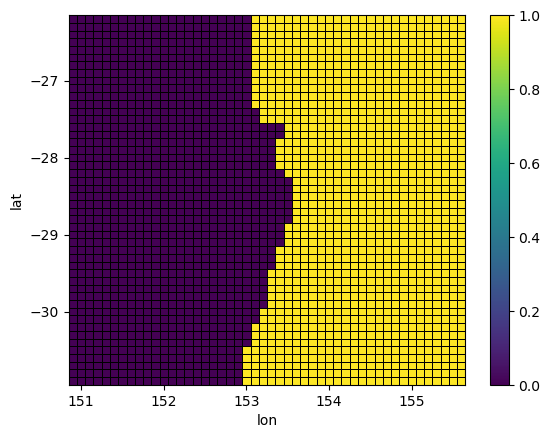

In [4]:
test_MOM.plot(edgecolors='black',linewidth=0.5)

In [5]:
print (f"""
Bounds of Domain are {test_MOM.lat.data.min()},{test_MOM.lat.data.max():.1f} latitude
                     {test_MOM.lon.data.min()}, {test_MOM.lon.data.max():.1f} longitude""")


Bounds of Domain are -30.9,-26.2 latitude
                     150.9, 155.6 longitude


In [6]:
# What if we naively try upscaling by by factor of 2?
test_MOM.lat.data

array([-30.9, -30.8, -30.7, -30.6, -30.5, -30.4, -30.3, -30.2, -30.1,
       -30. , -29.9, -29.8, -29.7, -29.6, -29.5, -29.4, -29.3, -29.2,
       -29.1, -29. , -28.9, -28.8, -28.7, -28.6, -28.5, -28.4, -28.3,
       -28.2, -28.1, -28. , -27.9, -27.8, -27.7, -27.6, -27.5, -27.4,
       -27.3, -27.2, -27.1, -27. , -26.9, -26.8, -26.7, -26.6, -26.5,
       -26.4, -26.3, -26.2])

In [7]:
test_MOM.lat.isel(lat=slice(0, None, 2)).data

array([-30.9, -30.7, -30.5, -30.3, -30.1, -29.9, -29.7, -29.5, -29.3,
       -29.1, -28.9, -28.7, -28.5, -28.3, -28.1, -27.9, -27.7, -27.5,
       -27.3, -27.1, -26.9, -26.7, -26.5, -26.3])

In [8]:
# It won't respect the corners for fields defined on vertices. So we'll have to do it another way

In [9]:
# Load the frankenmodel grids
FR_DIR = Path('/g/data/gb02/ab8992/frankenmodel-rundir')
fr_mask, = iris.load( FR_DIR / 'um_inputfiles/ancils/qrparm.mask')

In [10]:
fr_mask_da = xr.DataArray.from_iris(fr_mask)

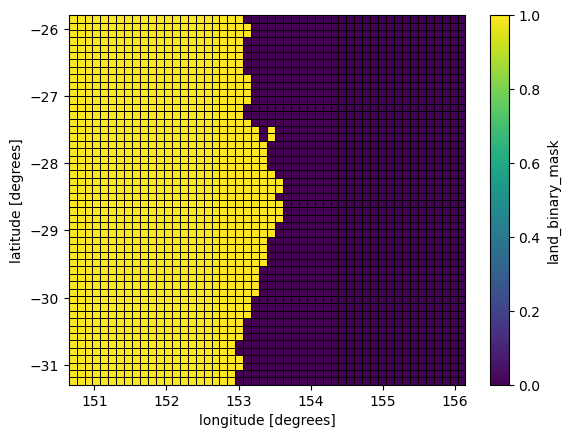

In [11]:
fr_mask_da.plot(edgecolors='black',linewidth=0.5)

In [12]:
fr_mesh = xr.load_dataset( FR_DIR / 'mom_inputfiles/access-rom3-ESMFmesh.nc')
fr_hgrid = xr.load_dataset( FR_DIR / 'mom_inputfiles/hgrid.nc')

In [13]:
geo_lon_t = fr_hgrid.x[1::2,1::2]
geo_lat_t = fr_hgrid.y[1::2,1::2]

lons = geo_lon_t.values[0,:]
lats = geo_lat_t.values[:,0]

nx = len(lons)
ny = len(lats)

fr_mom_da = xr.DataArray(fr_mesh.elementMask.values.reshape(ny,nx),
                        dims=['lat','lon'],
                        coords={'lat':lats, 
                                'lon':lons})

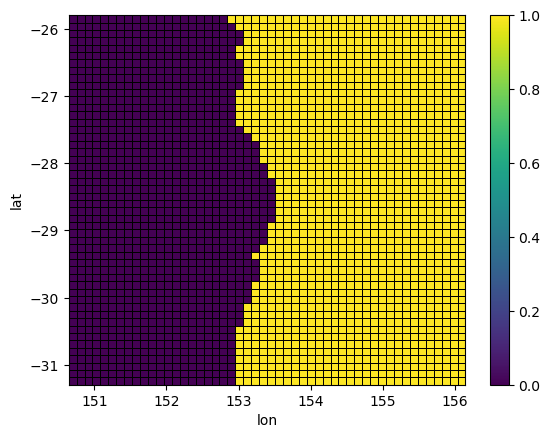

In [14]:
fr_mom_da.plot(edgecolors='black',linewidth=0.5)

In [15]:
# These are the same latitude values
(lats-fr_mask_da.latitude.data).sum()

-9.536743160509786e-06

In [16]:
# And longitude values
(lons-fr_mask_da.longitude.data).sum()

0.00015258789042604803

Text(0.5, 1.0, 'Delta')

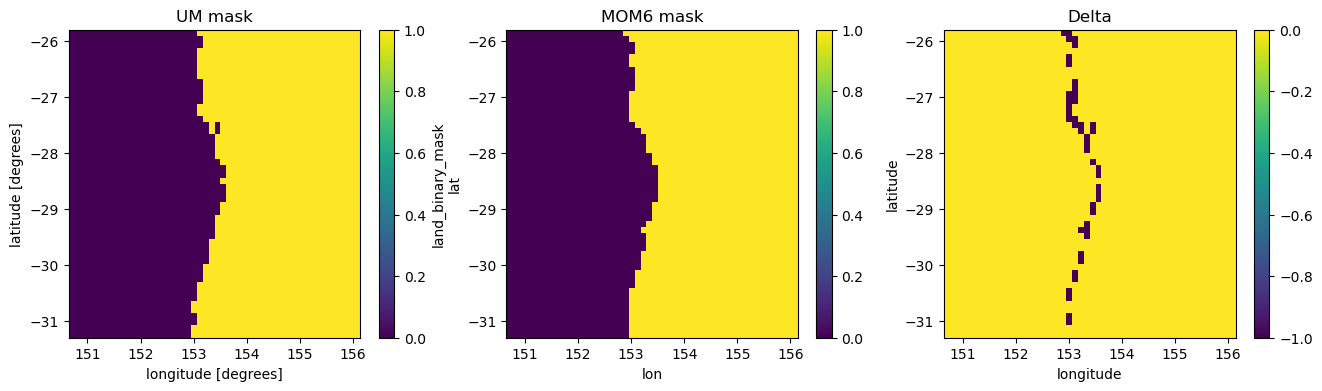

In [17]:
# But these masks aren't the same! 
fig,ax=plt.subplots(1,3,figsize=(16,4))
fr_invert = (1-fr_mask_da)
fr_invert.plot(ax=ax[0])
fr_mom_da.plot(ax=ax[1])
delta = fr_invert.data.compute() - fr_mom_da.data
delta_da = xr.DataArray(delta,
                        dims=['latitude','longitude'],
                        coords={'latitude':lats, 
                                'longitude':lons})
delta_da.plot(ax=ax[2])
ax[0].set_title('UM mask')
ax[1].set_title('MOM6 mask')
ax[2].set_title('Delta')

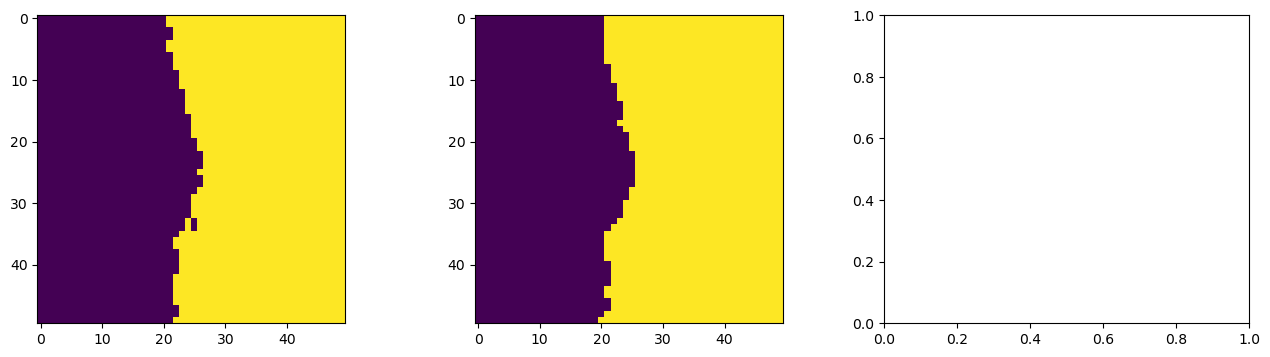

In [18]:
fig,ax=plt.subplots(1,3,figsize=(16,4))
ax[0].imshow(fr_invert.data)
ax[1].imshow(fr_mom_da.data)


In [19]:
fr_invert.drop_attrs().compute()

<xarray.DataArray 'land_binary_mask' (latitude: 50, longitude: 50)> Size: 20kB
array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]])
Coordinates:
  * latitude   (latitude) float32 200B -31.24 -31.13 -31.02 ... -25.96 -25.85
  * longitude  (longitude) float32 200B 150.7 150.8 150.9 ... 155.9 156.0 156.1

In [20]:
# Now, based on this issue over velocity at the Eastern Edge, https://github.com/21centuryweather/rCM3-ancil-suite/issues/1#issuecomment-4265929769,
# let's add an extra value of longitude along the eastern edge
shape = list(fr_mask.data.shape)
new_shape = [shape[0]+1,shape[1]]
new_data = np.array([new_shape])

In [21]:
dx = np.round(lons[1]-lons[0],2)
new_lons = np.append(lons,lons[-1]+dx)

In [22]:
new_lons

array([150.7 , 150.81, 150.92, 151.03, 151.14, 151.25, 151.36, 151.47,
       151.58, 151.69, 151.8 , 151.91, 152.02, 152.13, 152.24, 152.35,
       152.46, 152.57, 152.68, 152.79, 152.9 , 153.01, 153.12, 153.23,
       153.34, 153.45, 153.56, 153.67, 153.78, 153.89, 154.  , 154.11,
       154.22, 154.33, 154.44, 154.55, 154.66, 154.77, 154.88, 154.99,
       155.1 , 155.21, 155.32, 155.43, 155.54, 155.65, 155.76, 155.87,
       155.98, 156.09, 156.2 ])

In [24]:
fr_hgrid.x

<xarray.DataArray 'x' (nyp: 101, nxp: 101)> Size: 82kB
array([[150.645, 150.7  , 150.755, ..., 156.035, 156.09 , 156.145],
       [150.645, 150.7  , 150.755, ..., 156.035, 156.09 , 156.145],
       [150.645, 150.7  , 150.755, ..., 156.035, 156.09 , 156.145],
       ...,
       [150.645, 150.7  , 150.755, ..., 156.035, 156.09 , 156.145],
       [150.645, 150.7  , 150.755, ..., 156.035, 156.09 , 156.145],
       [150.645, 150.7  , 150.755, ..., 156.035, 156.09 , 156.145]])
Dimensions without coordinates: nyp, nxp
Attributes:
    units:    degrees

In [26]:
lons

array([150.7 , 150.81, 150.92, 151.03, 151.14, 151.25, 151.36, 151.47,
       151.58, 151.69, 151.8 , 151.91, 152.02, 152.13, 152.24, 152.35,
       152.46, 152.57, 152.68, 152.79, 152.9 , 153.01, 153.12, 153.23,
       153.34, 153.45, 153.56, 153.67, 153.78, 153.89, 154.  , 154.11,
       154.22, 154.33, 154.44, 154.55, 154.66, 154.77, 154.88, 154.99,
       155.1 , 155.21, 155.32, 155.43, 155.54, 155.65, 155.76, 155.87,
       155.98, 156.09])

In [31]:
FRANKEN_DIR = Path('/home/548/pag548/cylc-run/rCM3-frankenmodel/')

In [35]:
um_mask, = iris.load( FRANKEN_DIR / 'um_inputfiles/ancils/qrparm.mask')

In [36]:
um_mask_da = xr.DataArray.from_iris(um_mask)

In [38]:
um_mask_da.latitude

<xarray.DataArray 'latitude' (latitude: 50)> Size: 200B
array([-31.24    , -31.13    , -31.02    , -30.91    , -30.8     , -30.69    ,
       -30.58    , -30.47    , -30.36    , -30.25    , -30.14    , -30.029999,
       -29.92    , -29.81    , -29.7     , -29.59    , -29.48    , -29.369999,
       -29.26    , -29.15    , -29.039999, -28.93    , -28.82    , -28.71    ,
       -28.6     , -28.49    , -28.38    , -28.27    , -28.16    , -28.05    ,
       -27.94    , -27.83    , -27.72    , -27.61    , -27.5     , -27.39    ,
       -27.279999, -27.17    , -27.06    , -26.95    , -26.84    , -26.73    ,
       -26.619999, -26.51    , -26.4     , -26.29    , -26.18    , -26.07    ,
       -25.96    , -25.85    ], dtype=float32)
Coordinates:
  * latitude  (latitude) float32 200B -31.24 -31.13 -31.02 ... -25.96 -25.85
Attributes:
    standard_name:  latitude
    units:          degrees

In [39]:
um_mask_da.longitude

<xarray.DataArray 'longitude' (longitude: 50)> Size: 200B
array([150.7    , 150.81   , 150.92   , 151.03   , 151.14   , 151.25   ,
       151.36   , 151.47   , 151.58   , 151.69   , 151.8    , 151.91   ,
       152.02   , 152.12999, 152.23999, 152.34999, 152.45999, 152.56999,
       152.68   , 152.79   , 152.9    , 153.01   , 153.12   , 153.23   ,
       153.34   , 153.45   , 153.56   , 153.67   , 153.78   , 153.89   ,
       154.     , 154.11   , 154.22   , 154.33   , 154.44   , 154.55   ,
       154.66   , 154.77   , 154.87999, 154.98999, 155.09999, 155.20999,
       155.31999, 155.43   , 155.54   , 155.65   , 155.76   , 155.87   ,
       155.98   , 156.09   ], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 200B 150.7 150.8 150.9 ... 155.9 156.0 156.1
Attributes:
    standard_name:  longitude
    units:          degrees

In [40]:
# Specifying
#longitude_extent = [150.7, 156.09],  
# latitude_extent = [-31.24, -25.85],
#    resolution = 0.055, 

0.055

In [41]:
LISMORE_MOM6_DIR = Path('/g/data/gb02/pag548/rom3-inputdirs/rCM3-Lismore-demo')

In [42]:
lis_hgrid = xr.load_dataset( LISMORE_MOM6_DIR / 'hgrid.nc')

In [45]:
geo_lon_t = lis_hgrid.x[1::2,1::2]
geo_lat_t = lis_hgrid.y[1::2,1::2]

lons = geo_lon_t.values[0,:]
lats = geo_lat_t.values[:,0]

nx = len(lons)
ny = len(lats)

In [58]:
print ('Lat bounds')
print (f'{lis_hgrid.x[0,:3].data}...,{lis_hgrid.x[0,-3:].data}')
print ('Lon bounds')
print (f'{lis_hgrid.y[:3,0].data}...,{lis_hgrid.y[-3:,0].data}')

Lat bounds
[150.7    150.7275 150.755 ]...,[156.035  156.0625 156.09  ]
Lon bounds
[-31.24      -31.2159375 -31.191875 ]...,[-25.898125  -25.8740625 -25.85     ]


In [68]:
# Load some MOM6 output
MOM6_OUTPUT_DIR = Path('/g/data/gb02/pag548/rom3-inputdirs/rCM3-Lismore-demo/rundir/archive//rCM3-Lismore-demo/output000/')
geom = xr.open_dataset(MOM6_OUTPUT_DIR / 'ocean_geometry.nc')

In [69]:
geom

<xarray.Dataset> Size: 2MB
Dimensions:  (latq: 113, lonq: 99, lath: 112, lonh: 98)
Coordinates:
  * latq     (latq) float64 904B -31.24 -31.19 -31.14 ... -25.95 -25.9 -25.85
  * lonq     (lonq) float64 792B 150.7 150.8 150.8 150.9 ... 156.0 156.0 156.1
  * lath     (lath) float64 896B -31.22 -31.17 -31.12 ... -25.97 -25.92 -25.87
  * lonh     (lonh) float64 784B 150.7 150.8 150.8 150.9 ... 156.0 156.0 156.1
Data variables: (12/19)
    geolatb  (latq, lonq) float64 89kB ...
    geolonb  (latq, lonq) float64 89kB ...
    geolat   (lath, lonh) float64 88kB ...
    geolon   (lath, lonh) float64 88kB ...
    D        (lath, lonh) float64 88kB ...
    f        (latq, lonq) float64 89kB ...
    ...       ...
    dyBu     (latq, lonq) float64 89kB ...
    Ah       (lath, lonh) float64 88kB ...
    Aq       (latq, lonq) float64 89kB ...
    dxCvo    (latq, lonh) float64 89kB ...
    dyCuo    (lath, lonq) float64 89kB ...
    wet      (lath, lonh) float64 88kB ...
Attributes:
    NumFilesInSet:  1

In [72]:
tauv = xr.open_dataset(MOM6_OUTPUT_DIR / 'access-om3.mom6.2d.tauvo.1mon.mean._2012_01.nc',decode_timedelta=True)

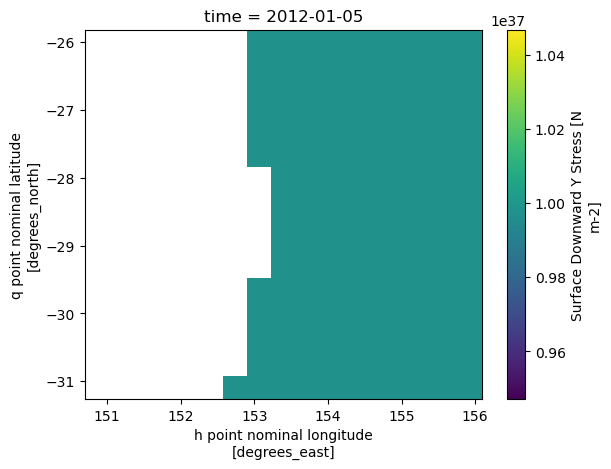

In [74]:
tauv.tauvo.plot()

In [76]:
salt = xr.open_dataset(MOM6_OUTPUT_DIR / 'access-om3.mom6.2d.salt_flux_added.1mon.mean._2012_01.nc',decode_timedelta=True)

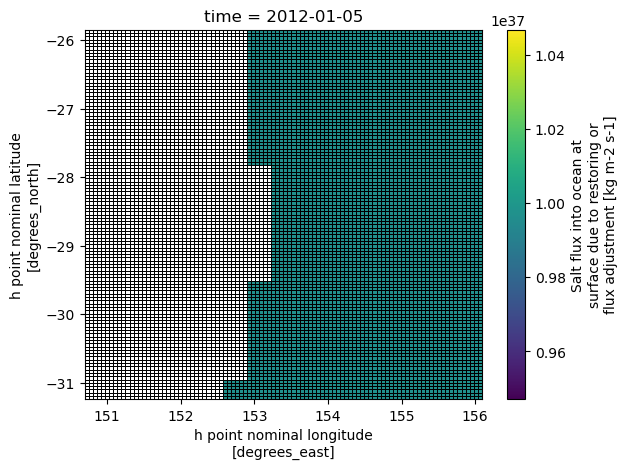

In [81]:
salt.salt_flux_added.plot(edgecolors='black',linewidth=0.5)

In [84]:
bathymetry = xr.load_dataset( LISMORE_MOM6_DIR / 'bathymetry.nc')

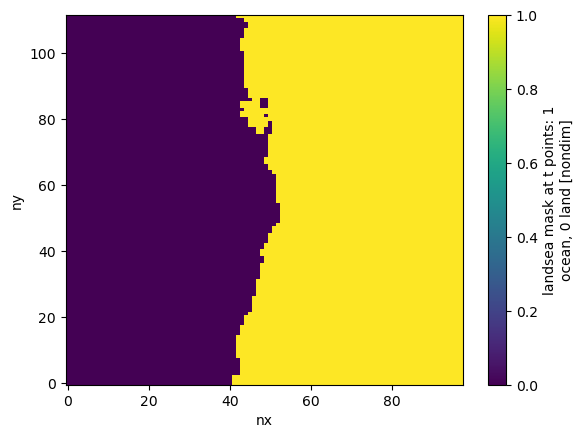

In [86]:
bathymetry.mask.plot()

In [87]:
MOM6_mask = xr.load_dataset( LISMORE_MOM6_DIR / 'access-rom3-ESMFmesh.nc')

In [89]:
MOM6_mask_da = xr.DataArray(MOM6_mask.elementMask.values.reshape(ny,nx),
                        dims=['lat','lon'],
                        coords={'lat':lats, 
                                'lon':lons})

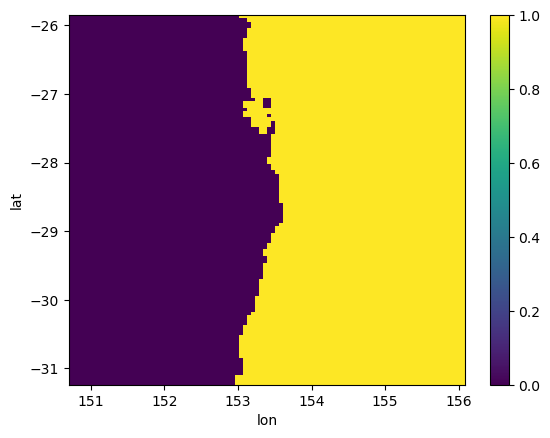

In [90]:
MOM6_mask_da.plot()

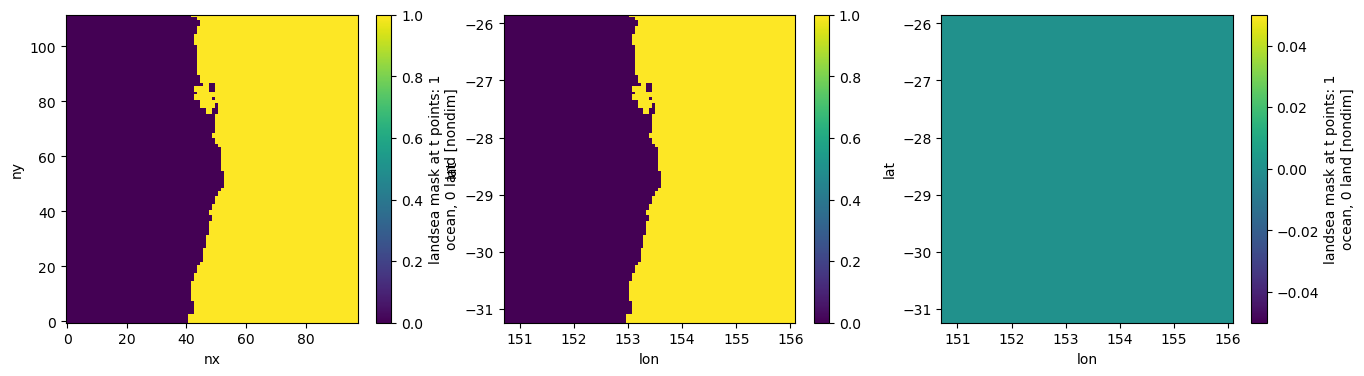

In [105]:
fig,ax=plt.subplots(1,3,figsize=(16,4))
bathymetry.mask.plot(ax=ax[0])
MOM6_mask_da.plot(ax=ax[1])
delta = bathymetry.mask.rename({'nx':'lon','ny':'lat'}) - MOM6_mask_da
delta.plot(ax=ax[2])

In [109]:
#Ok let's regrid the bathmetry onto the um_mask.
# longitude_extent = [150.7, 156.09],  
# latitude_extent = [-31.24, -25.85],

In [112]:
MOM6_mask_da.lat

<xarray.DataArray 'lat' (lat: 112)> Size: 896B
array([-31.215937, -31.167813, -31.119687, -31.071562, -31.023438, -30.975312,
       -30.927187, -30.879062, -30.830937, -30.782812, -30.734687, -30.686562,
       -30.638437, -30.590312, -30.542187, -30.494062, -30.445937, -30.397813,
       -30.349687, -30.301562, -30.253438, -30.205312, -30.157187, -30.109063,
       -30.060937, -30.012812, -29.964688, -29.916562, -29.868437, -29.820312,
       -29.772188, -29.724062, -29.675937, -29.627812, -29.579687, -29.531562,
       -29.483438, -29.435312, -29.387187, -29.339063, -29.290937, -29.242812,
       -29.194688, -29.146562, -29.098437, -29.050313, -29.002187, -28.954062,
       -28.905938, -28.857813, -28.809687, -28.761563, -28.713438, -28.665312,
       -28.617188, -28.569063, -28.520937, -28.472812, -28.424688, -28.376562,
       -28.328437, -28.280313, -28.232188, -28.184062, -28.135938, -28.087812,
       -28.039687, -27.991563, -27.943438, -27.895312, -27.847188, -27.799063,
       -27.750937, -27.702813, -27.654688, -27.606562, -27.558438, -27.510313,
       -27.462187, -27.414062, -27.365938, -27.317813, -27.269687, -27.221563,
       -27.173437, -27.125312, -27.077188, -27.029063, -26.980937, -26.932813,
       -26.884688, -26.836562, -26.788438, -26.740313, -26.692188, -26.644063,
       -26.595938, -26.547812, -26.499688, -26.451563, -26.403438, -26.355313,
       -26.307188, -26.259063, -26.210938, -26.162813, -26.114688, -26.066563,
       -26.018438, -25.970313, -25.922187, -25.874063])
Coordinates:
  * lat      (lat) float64 896B -31.22 -31.17 -31.12 ... -25.97 -25.92 -25.87